# BigMart Outlet Performance Analyzer

Generated on 2026-03-30 11:51:12

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


## Load Dataset

In [3]:
# Update path if needed
df = pd.read_csv("C:\\Users\\ACER\\Downloads\\BigMart Sales.csv")
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


## Config and Custom Exception

In [4]:
class InvalidOutletDataException(Exception):
    pass

class Config:
    CURRENT_YEAR = 2026
    SIZE_MAP = {'Small': 1000, 'Medium': 2000, 'High': 3000}
    ROLLING_WINDOW = 5


## Data Processor

In [5]:
class DataProcessor:

    def __init__(self, df):
        self.df = df.copy()

    def validate(self):
        required = ['Outlet_Identifier','Outlet_Establishment_Year',
                    'Outlet_Size','Outlet_Type','Item_Outlet_Sales']
        for col in required:
            if col not in self.df.columns:
                raise InvalidOutletDataException(f"{col} missing")

    def clean(self):
        if 'Item_Weight' in self.df.columns:
            self.df['Item_Weight'].fillna(self.df['Item_Weight'].mean(), inplace=True)

        if 'Item_Visibility' in self.df.columns:
            self.df['Item_Visibility'] = self.df['Item_Visibility'].replace(0, np.nan)
            self.df['Item_Visibility'].fillna(self.df['Item_Visibility'].mean(), inplace=True)

    def feature_engineering(self):
        self.df['Outlet_Age'] = Config.CURRENT_YEAR - self.df['Outlet_Establishment_Year']

    def remove_outliers(self):
        Q1 = self.df['Item_Outlet_Sales'].quantile(0.25)
        Q3 = self.df['Item_Outlet_Sales'].quantile(0.75)
        IQR = Q3 - Q1
        self.df = self.df[
            (self.df['Item_Outlet_Sales'] >= Q1 - 1.5*IQR) &
            (self.df['Item_Outlet_Sales'] <= Q3 + 1.5*IQR)
        ]

    def normalize(self):
        self.df['Normalized_Sales'] = (
            (self.df['Item_Outlet_Sales'] - np.mean(self.df['Item_Outlet_Sales'])) /
            np.std(self.df['Item_Outlet_Sales'])
        )

    def rolling(self):
        self.df['Rolling_Sales'] = self.df['Item_Outlet_Sales'].rolling(Config.ROLLING_WINDOW).mean()

    def process(self):
        self.validate()
        self.clean()
        self.feature_engineering()
        self.remove_outliers()
        self.normalize()
        self.rolling()
        return self.df


## Metrics Calculator

In [6]:
class MetricsCalculator:

    def __init__(self, df):
        self.df = df

    def avg_sales(self):
        return self.df.groupby(['Outlet_Identifier','Item_Identifier'])['Item_Outlet_Sales'].mean()

    def sales_density(self):
        self.df['Size_Value'] = self.df['Outlet_Size'].map(Config.SIZE_MAP)
        self.df['Sales_Density'] = self.df['Item_Outlet_Sales'] / self.df['Size_Value']
        return self.df

    def performance(self):
        return {
            "size": self.df.groupby('Outlet_Size')['Item_Outlet_Sales'].mean(),
            "type": self.df.groupby('Outlet_Type')['Item_Outlet_Sales'].mean(),
            "age": self.df.groupby(pd.cut(self.df['Outlet_Age'],3))['Item_Outlet_Sales'].mean()
        }

    def underperforming(self):
        outlet_avg = self.df.groupby('Outlet_Identifier')['Item_Outlet_Sales'].mean()
        return outlet_avg[outlet_avg < outlet_avg.mean()]

    def high_potential(self):
        return self.df.groupby(['Outlet_Type','Outlet_Size'])['Item_Outlet_Sales']                      .mean().sort_values(ascending=False)


## Simulation Engine

In [7]:
class SimulationEngine:

    def __init__(self, df):
        self.df = df

    def expansion(self, top_n=3, new_outlets=5):
        top = self.df.groupby(['Outlet_Type','Outlet_Size'])['Item_Outlet_Sales']                     .mean().sort_values(ascending=False).head(top_n)

        projection = {}
        for k, v in top.items():
            projection[k] = v * new_outlets

        return projection


## Visualization Engine

In [8]:
class VisualizationEngine:

    def __init__(self, df):
        self.df = df

    def bar_plot(self):
        data = self.df.groupby('Outlet_Size')['Item_Outlet_Sales'].mean()
        plt.figure()
        plt.bar(data.index, data.values)
        plt.title("Outlet Size vs Sales")
        plt.xlabel("Outlet Size")
        plt.ylabel("Average Sales")
        plt.show()

    def heatmap(self):
        pivot = self.df.pivot_table(
            values='Item_Outlet_Sales',
            index='Outlet_Size',
            columns='Outlet_Type',
            aggfunc='mean'
        )
        plt.figure(figsize=(10,6))
        sns.heatmap(pivot, annot=True, cmap="coolwarm")
        plt.title("Outlet Type vs Size Heatmap")
        plt.show()


## Run Analysis

C:\Users\ACER\AppData\Local\Temp\ipykernel_21116\2965044266.py:15: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  self.df['Item_Weight'].fillna(self.df['Item_Weight'].mean(), inplace=True)
C:\Users\ACER\AppData\Local\Temp\ipykernel_21116\2965044266.py:19: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series 

Underperforming Outlets:
Outlet_Identifier
OUT010    339.351662
OUT019    340.329723
Name: Item_Outlet_Sales, dtype: float64

Top Categories:
Outlet_Type        Outlet_Size
Supermarket Type3  Medium         3174.872101
Supermarket Type1  Medium         2291.892251
                   Small          2287.983582
                   High           2217.100205
Supermarket Type2  Medium         1980.230278
Name: Item_Outlet_Sales, dtype: float64

Expansion Projection:
{('Supermarket Type3', 'Medium'): 15874.360507211535, ('Supermarket Type1', 'Medium'): 11459.461255712731, ('Supermarket Type1', 'Small'): 11439.917908396947}


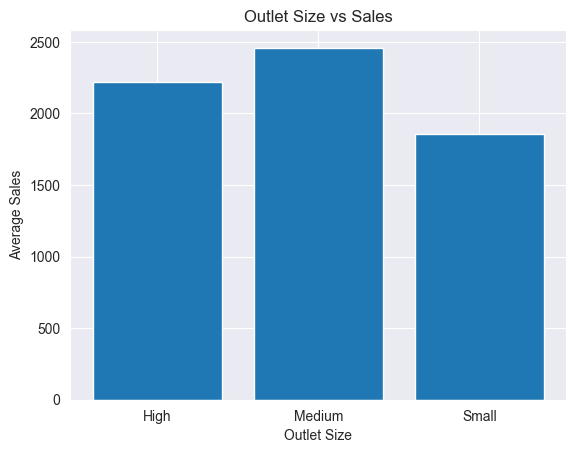

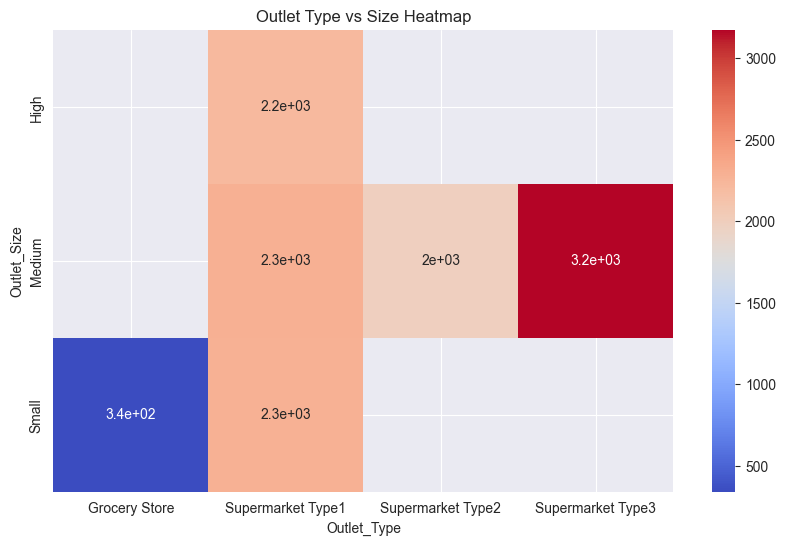

In [9]:
processor = DataProcessor(df)
df_processed = processor.process()

metrics = MetricsCalculator(df_processed)
print("Underperforming Outlets:")
print(metrics.underperforming())

print("\nTop Categories:")
print(metrics.high_potential().head())

sim = SimulationEngine(df_processed)
print("\nExpansion Projection:")
print(sim.expansion())

viz = VisualizationEngine(df_processed)
viz.bar_plot()
viz.heatmap()
